In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Load Data

In [ ]:
# Pastikan file 'track_data_final.csv' ada di folder yang sama
df = pd.read_csv('/content/track_data_final.csv')

In [ ]:
print(df.head())

                 track_id                           track_name  track_number  \
0  6pymOcrCnMuCWdgGVTvUgP                                    3            57   
1  2lWc1iJlz2NVcStV5fbtPG                               Clouds             1   
2  1msEuwSBneBKpVCZQcFTsU  Forever & Always (Taylor’s Version)            11   
3  7bcy34fBT2ap1L4bfPsl9q            I Didn't Change My Number             2   
4  0GLfodYacy3BJE7AI3A8en                             Man Down             7   

   track_popularity  track_duration_ms  explicit     artist_name  \
0                61             213173     False  Britney Spears   
1                67             158760     False           BUNT.   
2                63             225328     False    Taylor Swift   
3                72             158463      True   Billie Eilish   
4                57             267013     False         Rihanna   

   artist_popularity  artist_followers      artist_genres  \
0               80.0        17755451.0           

Feature (Membuat Target)

In [ ]:
# Kita definisikan: Lagu Populer = Popularity > 50 (Nilai 1), Sisanya 0
df['is_popular'] = df['track_popularity'].apply(lambda x: 1 if x > 50 else 0)

In [ ]:
# Cek sebaran data (agar tahu apakah data seimbang/tidak)
print("Sebaran Data Target (0 = Tidak Populer, 1 = Populer):")
print(df['is_popular'].value_counts())

Sebaran Data Target (0 = Tidak Populer, 1 = Populer):
is_popular
1    5352
0    3426
Name: count, dtype: int64


Memilih Fitur (X)

In [ ]:
# Kita pilih kolom yang logis mempengaruhi popularitas
feature_cols = ['track_duration_ms', 'artist_popularity', 'artist_followers', 'album_total_tracks', 'explicit']

In [ ]:
# Buat dataframe X (Fitur) dan y (Target)
X = df[feature_cols].copy()
y = df['is_popular']

Data Cleaning

In [ ]:
# Karena ada data kosong di artist_popularity/followers, kita hapus baris yang kosong
# Gabungkan dulu X dan y agar baris yang dihapus sinkron
data_bersih = pd.concat([X, y], axis=1).dropna()

In [ ]:
# Pisahkan lagi setelah dibersihkan
X = data_bersih[feature_cols]
y = data_bersih['is_popular']

In [ ]:
# Konversi boolean (True/False) ke angka (1/0) untuk kolom 'explicit'
X['explicit'] = X['explicit'].astype(int)

/tmp/ipython-input-2160626896.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['explicit'] = X['explicit'].astype(int)


Splitting Data (80% Latih, 20% Uji)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Modeling Random Forest

In [ ]:
print("\nSedang melatih model...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


Sedang melatih model...


RandomForestClassifier(random_state=42)

Evaluasi

In [ ]:
y_pred = model.predict(X_test)

print("\n=== HASIL AKHIR ===")
print("Akurasi Model:", accuracy_score(y_test, y_pred))
print("\nLaporan Detail:")
print(classification_report(y_test, y_pred))


=== HASIL AKHIR ===
Akurasi Model: 0.764102564102564

Laporan Detail:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       702
           1       0.79      0.82      0.81      1053

    accuracy                           0.76      1755
   macro avg       0.75      0.75      0.75      1755
weighted avg       0.76      0.76      0.76      1755



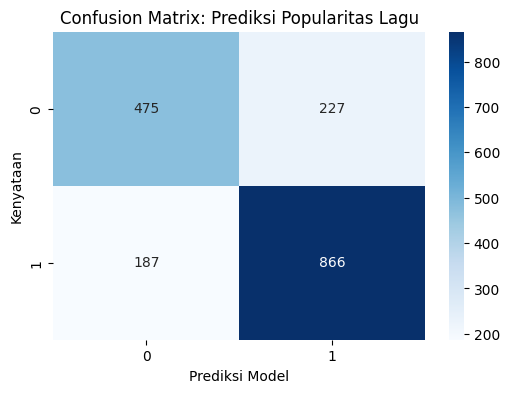

In [ ]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Prediksi Popularitas Lagu')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan')
plt.show()

Cek Fitur Terpenting

In [ ]:
# Melihat faktor apa yang paling bikin lagu jadi populer
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nFaktor Paling Berpengaruh:")
print(importances)


Faktor Paling Berpengaruh:
artist_followers      0.317203
track_duration_ms     0.252391
artist_popularity     0.248705
album_total_tracks    0.161928
explicit              0.019773
dtype: float64


Uji Coba Model dengan Data Baru (Simulasi)

In [ ]:
# === PREDIKSI LAGU BARU ===

# Kita buat data lagu khayalan
lagu_baru = pd.DataFrame({
    'track_duration_ms': [180000],      # 3 menit (180.000 ms)
    'artist_popularity': [70],          # Artis sangat terkenal (skala 0-100)
    'artist_followers': [50000000],     # Follower 50 Juta
    'album_total_tracks': [12],         # Ada 12 lagu di albumnya
    'explicit': [0]                     # Tidak kasar (0)
})

print("Mencoba memprediksi lagu baru...")
prediksi = model.predict(lagu_baru)
probabilitas = model.predict_proba(lagu_baru)

# Tampilkan hasil
if prediksi[0] == 1:
    print(f"Hasil: POPULER! (Yakin {probabilitas[0][1]*100:.2f}%)")
else:
    print(f"Hasil: TIDAK POPULER. (Yakin {probabilitas[0][0]*100:.2f}%)")

Mencoba memprediksi lagu baru...
Hasil: POPULER! (Yakin 88.50%)


Menyimpan Model (Deployment)

In [ ]:
import joblib

# Simpan model ke file
joblib.dump(model, 'model_prediksi_lagu_v1.pkl')
print("Model berhasil disimpan sebagai 'model_prediksi_lagu_v1.pkl'")

Model berhasil disimpan sebagai 'model_prediksi_lagu_v1.pkl'
